# 02 · Generated Ligands & Metrics

Inspect the output of `sample.py` for a chosen pocket and compute aggregate metrics across all sampled pockets.

| Section | Contents |
|---|---|
| 1 | Config — `SAMPLE_DIR`, `TARGET_IDX` |
| 2 | Load pocket / GT ligand / generated samples |
| 3 | Interactive 3D viewer (Plotly) |
| 4 | 2D molecule grid + per-molecule metrics |
| 5 | Aggregate metrics across all targets |


In [1]:
import math, re, sys
from io import BytesIO
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from PIL import Image
from IPython.display import display

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem.Draw import rdMolDraw2D
RDLogger.DisableLog("rdApp.*")

# Resolve VoxBind root and sibling TargetDIff independent of kernel cwd.
HERE = Path.cwd().resolve()
VOXBIND = next((p for p in [HERE, *HERE.parents] if p.name == "VoxBind"), None)
if VOXBIND is None:
    raise RuntimeError(f"Could not locate VoxBind project root from cwd={HERE}")
TARGETDIFF = VOXBIND.parent / "TargetDIff"  # note: case-sensitive
if not TARGETDIFF.exists():
    raise FileNotFoundError(f"TargetDIff not found at {TARGETDIFF}")

for p in (str(VOXBIND), str(TARGETDIFF)):
    if p not in sys.path:
        sys.path.insert(0, p)

from utils.evaluation.scoring_func import get_chem  # from TargetDIff

plt.rcParams.update({"figure.dpi": 120, "font.size": 9})
ELEM_COLOR = {"C": "gray", "N": "cornflowerblue", "O": "tomato",
              "S": "gold",  "F": "limegreen",     "Cl": "lime", "P": "orange"}
ELEM_SIZE  = {"C": 3.5, "N": 3.5, "O": 3.2, "S": 4.5,
              "F": 2.8, "Cl": 4.0, "P": 4.0}


## 1. Config

`SAMPLE_DIR` should contain `target_*/` subdirectories with a `samples.sdf` and the pocket PDB / GT ligand SDF (the format produced by `sample.py`).

In [10]:
SAMPLE_DIR = Path("/home/shpark/prj-denovo/VoxBind/voxbind/exps/260514_voxbind_100ep340") / "samples" / "res_train_thresh010"
TARGET_IDX = 0

SAMPLE_DIR  = SAMPLE_DIR.resolve()
target_dirs = sorted(SAMPLE_DIR.glob("target_*"))
print(f"Sample dir   : {SAMPLE_DIR}")
print(f"Targets found: {len(target_dirs)}")
for td in target_dirs:
    sdf = td / "samples.sdf"
    n = len(list(Chem.SDMolSupplier(str(sdf), sanitize=False))) if sdf.exists() else 0
    print(f"  {td.name}  —  {n} generated mols")


Sample dir   : /home/shpark/prj-denovo/VoxBind/voxbind/exps/260514_voxbind_100ep340/samples/res_train_thresh010
Targets found: 2
  target_00  —  4 generated mols
  target_01  —  0 generated mols


## 2. Load pocket, GT ligand, generated samples

In [11]:
def parse_pocket_pdb(pdb_path):
    coords, elems = [], []
    for line in open(pdb_path):
        if not (line.startswith("ATOM") or line.startswith("HETATM")):
            continue
        try:
            x, y, z = float(line[30:38]), float(line[38:46]), float(line[46:54])
        except ValueError:
            continue
        elem = line[76:78].strip() if len(line) > 76 else ""
        if not elem:
            elem = re.sub(r"[^A-Za-z]", "", line[12:16]).strip()[:2].capitalize()
        if elem in ("H", "D"):
            continue
        coords.append([x, y, z]); elems.append(elem)
    return np.array(coords, dtype=float), elems

def mol_coords(mol):
    conf = mol.GetConformer()
    return np.array([conf.GetAtomPosition(i) for i in range(mol.GetNumAtoms())])

def mol_elems(mol):
    return [a.GetSymbol() for a in mol.GetAtoms()]

def load_target(td: Path):
    pdb = next(iter(sorted(td.glob("*_pocket10.pdb"))), None)
    if pdb is None:
        raise FileNotFoundError(f"No pocket PDB in {td}")
    poc_xyz, poc_el = parse_pocket_pdb(str(pdb))

    gt_sdf = next((p for p in td.glob("*.sdf") if p.name != "samples.sdf"), None)
    gt = next(iter(Chem.SDMolSupplier(str(gt_sdf), removeHs=True, sanitize=True)), None) if gt_sdf else None

    gen = []
    samples_sdf = td / "samples.sdf"
    if samples_sdf.exists():
        gen = [m for m in Chem.SDMolSupplier(str(samples_sdf), removeHs=False, sanitize=True) if m is not None]
    return poc_xyz, poc_el, gt, gen, pdb.stem

td = target_dirs[TARGET_IDX]
poc_coords, poc_elems, gt_mol, gen_mols, pocket_name = load_target(td)

print(f"Target       : {td.name}")
print(f"Pocket       : {pocket_name}  ({len(poc_coords)} heavy atoms)")
print(f"GT ligand    : {'found' if gt_mol else 'not found'}",
      f"({gt_mol.GetNumAtoms()} atoms)" if gt_mol else "")
print(f"Generated    : {len(gen_mols)} molecules")


Target       : target_00
Pocket       : COMT_MOUSE_44_264_0__5p8y_A_rec_5p9s_7jk_lig_tt_docked_0_pocket10  (302 heavy atoms)
GT ligand    : found (27 atoms)
Generated    : 4 molecules


## 3. Interactive 3D viewer

Pocket (translucent grey) + GT ligand (large, outlined) + generated ligands (one trace per molecule).

In [12]:
palette = px.colors.qualitative.Plotly + px.colors.qualitative.Safe
traces = []

# Pocket — semi-transparent
for elem in sorted(set(poc_elems)):
    mask = [i for i, e in enumerate(poc_elems) if e == elem]
    xyz  = poc_coords[mask]
    traces.append(go.Scatter3d(
        x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
        mode="markers",
        marker=dict(size=ELEM_SIZE.get(elem, 3),
                    color=ELEM_COLOR.get(elem, "white"), opacity=0.20),
        name=f"Pocket {elem}", legendgroup="pocket",
    ))

# GT ligand — diamonds, white outline
if gt_mol is not None:
    gt_xyz, gt_elems = mol_coords(gt_mol), mol_elems(gt_mol)
    for elem in sorted(set(gt_elems)):
        mask = [i for i, e in enumerate(gt_elems) if e == elem]
        xyz  = gt_xyz[mask]
        traces.append(go.Scatter3d(
            x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
            mode="markers",
            marker=dict(size=ELEM_SIZE.get(elem, 3.5) * 1.8,
                        color=ELEM_COLOR.get(elem, "purple"),
                        opacity=0.95, symbol="diamond",
                        line=dict(width=1.5, color="white")),
            name=f"GT {elem}", legendgroup="gt",
        ))

# Generated ligands — one trace per molecule, distinct colours
for i, mol in enumerate(gen_mols):
    xyz, elems = mol_coords(mol), mol_elems(mol)
    color = palette[i % len(palette)]
    smi   = Chem.MolToSmiles(mol)
    traces.append(go.Scatter3d(
        x=xyz[:, 0], y=xyz[:, 1], z=xyz[:, 2],
        mode="markers",
        marker=dict(size=6, color=color, opacity=0.85,
                    line=dict(width=0.6, color="white")),
        name=f"Gen {i}: {smi[:34]}{'…' if len(smi) > 34 else ''}",
        legendgroup=f"gen_{i}",
        text=elems,
        hovertemplate="%{text}<br>(%{x:.2f}, %{y:.2f}, %{z:.2f})<extra>Gen %{fullData.name}</extra>",
    ))

fig = go.Figure(traces)
fig.update_layout(
    title=f"{td.name}  —  pocket {len(poc_coords)} atoms · GT · {len(gen_mols)} generated",
    scene=dict(xaxis_title="X (\u00c5)", yaxis_title="Y (\u00c5)",
               zaxis_title="Z (\u00c5)", aspectmode="data"),
    width=900, height=650,
    legend=dict(itemsizing="constant", groupclick="toggleitem"),
    margin=dict(l=0, r=0, t=50, b=0),
)
fig.show()


### 3b. NGLViewer — single generated sample

Change `SAMPLE_IDX` to pick which generated molecule to inspect. Pocket is shown as a translucent cartoon + surface; GT ligand is magenta; the selected sample is element-coloured ball-and-stick.

In [14]:
SAMPLE_IDX = 0

import tempfile
import nglview as nv

assert 0 <= SAMPLE_IDX < len(gen_mols), (
    f"SAMPLE_IDX={SAMPLE_IDX} out of range [0, {len(gen_mols)})"
)

pocket_pdb = next(iter(sorted(td.glob("*_pocket10.pdb"))))


def _mol_to_sdf_path(mol):
    f = tempfile.NamedTemporaryFile(suffix=".sdf", delete=False, mode="w")
    w = Chem.SDWriter(f.name); w.write(mol); w.close()
    return f.name


view = nv.NGLWidget(width="900px", height="900px")

# Pocket — translucent cartoon + light surface
pocket_comp = view.add_component(str(pocket_pdb))
pocket_comp.clear_representations()
pocket_comp.add_cartoon(color="lightgrey", opacity=0.7)
pocket_comp.add_surface(color="lightgrey", opacity=0.10)

# GT ligand — magenta ball-and-stick (reference)
if gt_mol is not None:
    gt_comp = view.add_component(_mol_to_sdf_path(gt_mol))
    gt_comp.clear_representations()
    gt_comp.add_ball_and_stick(color="magenta", aspectRatio=1.5)

# Selected generated sample — element-coloured ball-and-stick
sel_mol = gen_mols[SAMPLE_IDX]
sel_comp = view.add_component(_mol_to_sdf_path(sel_mol))
sel_comp.clear_representations()
sel_comp.add_ball_and_stick(color="element", aspectRatio=1.5)

view.center()
print(f"Target     : {td.name}")
print(f"Sample idx : {SAMPLE_IDX} / {len(gen_mols) - 1}")
print(f"SMILES     : {Chem.MolToSmiles(sel_mol)}")
view

Target     : target_00
Sample idx : 0 / 3
SMILES     : CCC


NGLWidget()

## 4. 2D molecule grid + per-molecule metrics

RDKit 2D depictions with QED / SA / LogP / Lipinski / heavy-atom count.

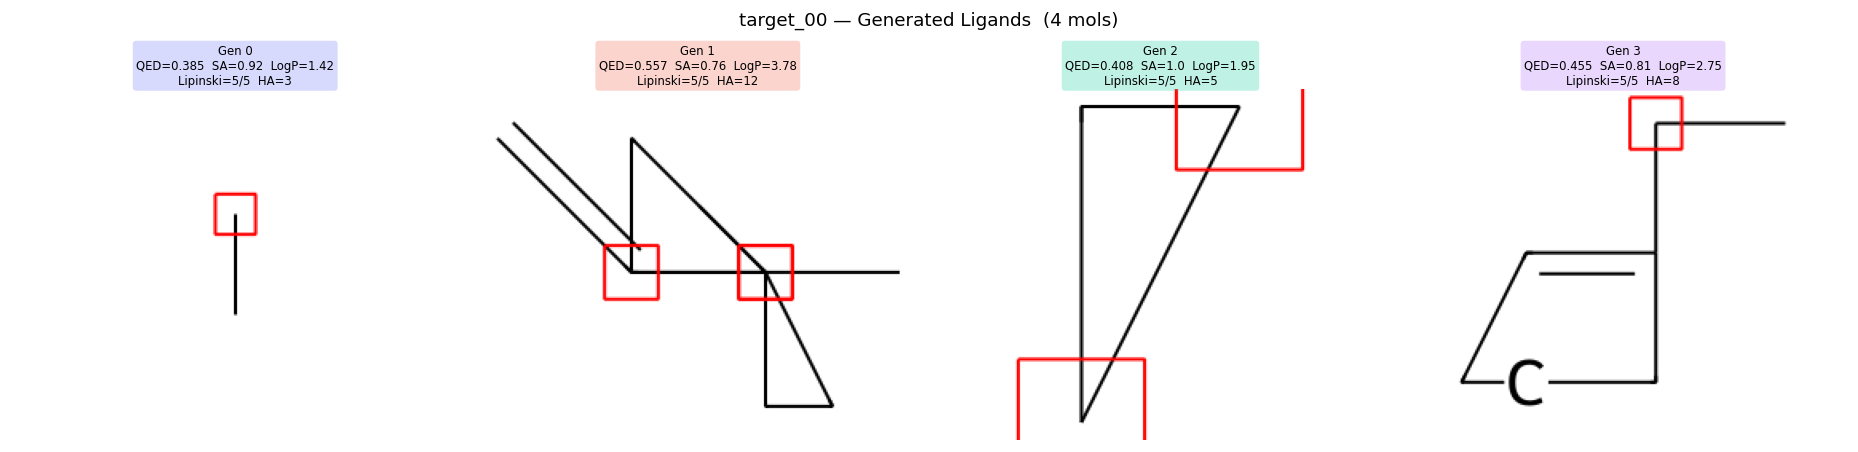

In [6]:
def mol_to_pil(mol: Chem.Mol, size=(280, 220)) -> Image.Image:
    """Render an RDKit mol to a PIL image."""
    drawer = rdMolDraw2D.MolDraw2DCairo(*size)
    drawer.drawOptions().addStereoAnnotation = True
    drawer.DrawMolecule(mol)
    drawer.FinishDrawing()
    return Image.open(BytesIO(drawer.GetDrawingText()))


def compute_metrics(mol: Chem.Mol) -> dict:
    c = get_chem(mol)
    return {
        "QED":      round(c["qed"], 3),
        "SA":       round(c["sa"], 2),
        "LogP":     round(c["logp"], 2),
        "Lipinski": int(c["lipinski"]),
        "HAtoms":   mol.GetNumHeavyAtoms(),
    }


# ── draw grid ─────────────────────────────────────────────────────────────────
n_cols = 4
n_rows = math.ceil(len(gen_mols) / n_cols)
mol_w, mol_h = 280, 220
panel_h = mol_h + 58          # extra space for text

fig_grid, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * mol_w / 72, n_rows * panel_h / 72),
)
axes = np.array(axes).reshape(-1)   # flatten

for i, mol in enumerate(gen_mols):
    ax = axes[i]
    img = mol_to_pil(mol, size=(mol_w, mol_h))
    ax.imshow(img)
    ax.axis("off")

    m = compute_metrics(mol)
    smi = Chem.MolToSmiles(mol)
    color = palette[i % len(palette)]
    ax.set_title(
        f"Gen {i}\n"
        f"QED={m['QED']}  SA={m['SA']}  LogP={m['LogP']}\n"
        f"Lipinski={m['Lipinski']}/5  HA={m['HAtoms']}",
        fontsize=7,
        pad=3,
        bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.25, linewidth=0),
    )

# hide unused axes
for j in range(len(gen_mols), len(axes)):
    axes[j].set_visible(False)

fig_grid.suptitle(
    f"{td.name} — Generated Ligands  ({len(gen_mols)} mols)",
    fontsize=11, y=1.01,
)
fig_grid.tight_layout()
plt.show()

## 5. Aggregate metrics across targets

Per-target validity, uniqueness, diversity, QED, SA, LogP, Lipinski — then mean across all targets.

In [7]:
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")


def tanimoto_diversity(mols):
    if len(mols) < 2:
        return float("nan")
    fps  = [Chem.RDKFingerprint(m) for m in mols]
    sims = [DataStructs.TanimotoSimilarity(fps[i], fps[j])
            for i in range(len(fps)) for j in range(i+1, len(fps))]
    return 1.0 - float(np.mean(sims))


rows = []
for _td in target_dirs:
    sdf_path = _td / "samples.sdf"
    if not sdf_path.exists():
        continue
    raw   = list(Chem.SDMolSupplier(str(sdf_path), sanitize=False))
    valid = [m for m in Chem.SDMolSupplier(str(sdf_path), sanitize=True)
             if m is not None and "." not in Chem.MolToSmiles(m)]

    if not valid:
        rows.append({"target": _td.name, "n_total": len(raw), "n_valid": 0})
        continue

    smiles  = [Chem.MolToSmiles(m) for m in valid]
    chems   = [get_chem(m) for m in valid]
    rows.append({
        "target":     _td.name,
        "n_total":    len(raw),
        "n_valid":    len(valid),
        "validity":   len(valid) / len(raw),
        "uniqueness": len(set(smiles)) / len(valid),
        "diversity":  tanimoto_diversity(valid),
        "qed":        np.mean([c["qed"]      for c in chems]),
        "sa":         np.mean([c["sa"]       for c in chems]),
        "logp":       np.mean([c["logp"]     for c in chems]),
        "lipinski":   np.mean([c["lipinski"] for c in chems]),
    })

# ── print summary table ───────────────────────────────────────────────────────
valid_rows = [r for r in rows if r.get("n_valid", 0) > 0]

def col_mean(key):
    vals = [r[key] for r in valid_rows if key in r and not np.isnan(r[key])]
    return np.mean(vals) if vals else float("nan")

keys = ["validity", "uniqueness", "diversity", "qed", "sa", "logp", "lipinski"]
print(f"Targets evaluated : {len(valid_rows)} / {len(rows)}")
print()
print(f"{'Metric':<14}  {'Mean':>8}")
print("-" * 25)
for k in keys:
    print(f"  {k:<12}  {col_mean(k):8.4f}")

Targets evaluated : 1 / 1

Metric              Mean
-------------------------
  validity        1.0000
  uniqueness      1.0000
  diversity       0.8585
  qed             0.4515
  sa              0.8725
  logp            2.4746
  lipinski        5.0000


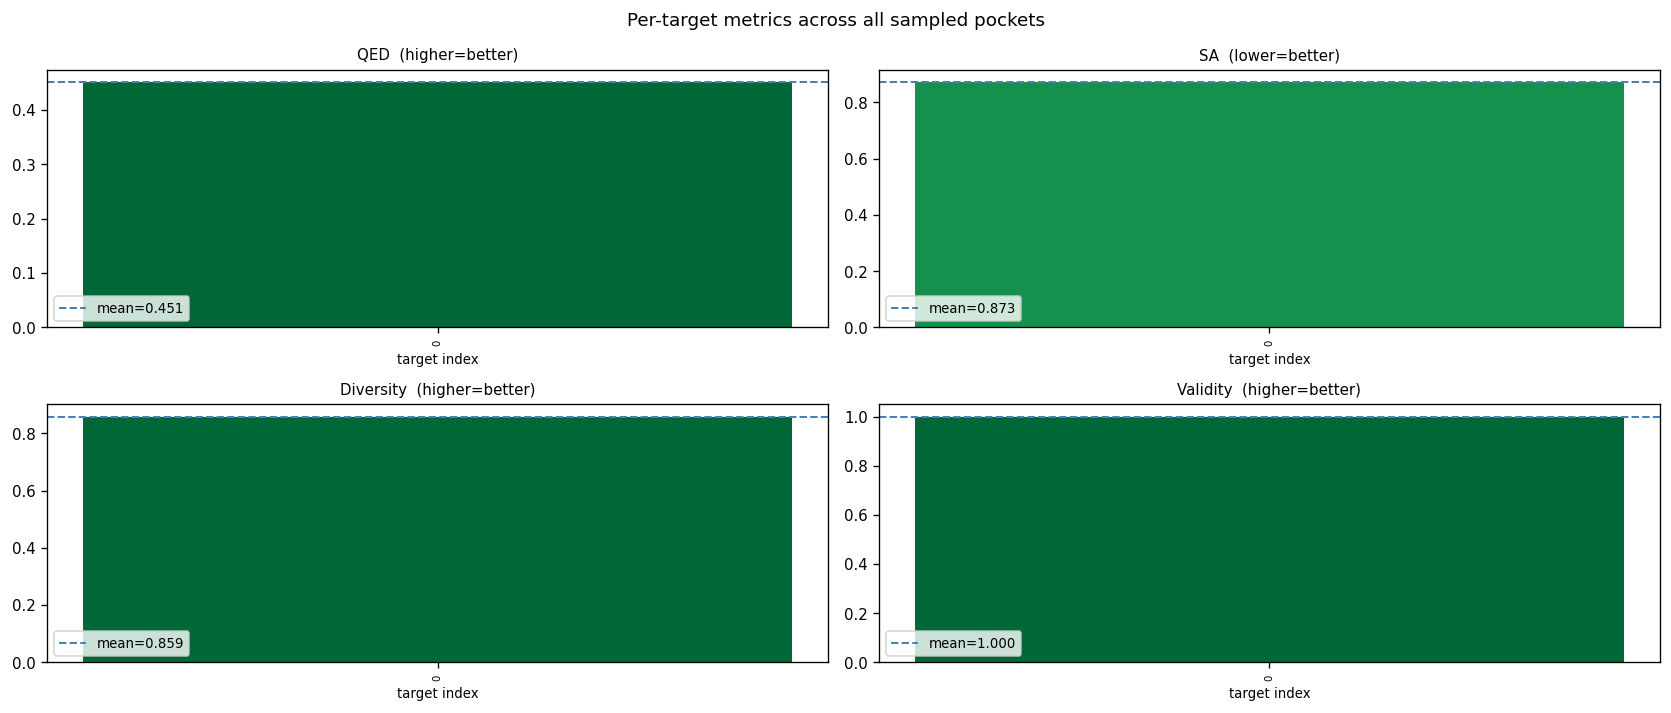

In [8]:
# ── Bar plots of per-target metrics ──────────────────────────────────────────
df = pd.DataFrame(valid_rows).set_index("target")

plot_keys = [("qed", "QED", "higher=better"),
             ("sa",  "SA",  "lower=better"),
             ("diversity", "Diversity", "higher=better"),
             ("validity",  "Validity",  "higher=better")]

fig_bar, axes = plt.subplots(2, 2, figsize=(14, 6))
for ax, (col, label, hint) in zip(axes.flatten(), plot_keys):
    vals = df[col].dropna()
    colors = [plt.cm.RdYlGn(v / vals.max()) if col != "sa"
              else plt.cm.RdYlGn(1 - v / 10) for v in vals]
    ax.bar(range(len(vals)), vals.values, color=colors, edgecolor="none")
    ax.axhline(vals.mean(), color="steelblue", ls="--", lw=1.2,
               label=f"mean={vals.mean():.3f}")
    ax.set_title(f"{label}  ({hint})", fontsize=9)
    ax.set_xlabel("target index", fontsize=8)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(range(len(vals)), fontsize=6, rotation=90)
    ax.legend(fontsize=8)

fig_bar.suptitle("Per-target metrics across all sampled pockets", fontsize=11)
fig_bar.tight_layout()
plt.show()

In [9]:
# ── Interactive scatter: QED vs SA coloured by diversity ─────────────────────
df2 = df.reset_index()

fig_scatter = go.Figure(go.Scatter(
    x=df2["sa"],
    y=df2["qed"],
    mode="markers+text",
    text=df2["target"],
    textposition="top center",
    textfont=dict(size=7),
    marker=dict(
        size=df2["n_valid"] * 3,
        color=df2["diversity"],
        colorscale="Viridis",
        showscale=True,
        colorbar=dict(title="Diversity", thickness=12, len=0.7),
        opacity=0.8,
        line=dict(width=0.5, color="white"),
    ),
    hovertemplate=(
        "<b>%{text}</b><br>"
        "SA=%{x:.2f}  QED=%{y:.3f}<br>"
        "Diversity=%{marker.color:.3f}<extra></extra>"
    ),
))
fig_scatter.update_layout(
    title="QED vs SA — bubble size = # valid mols, colour = diversity",
    xaxis_title="SA score  (lower = easier to synthesise)",
    yaxis_title="QED  (higher = more drug-like)",
    width=800, height=520,
)
fig_scatter.show()